# Pipeline CD - Coleta de Dados
## Trilha C: risco de baixa produtividade agrícola
### ETAPA 1 - Coleta e preservação do dado bruto

1. **Configuração**: parâmetros de local, período e variáveis reunidos em um único lugar;
2. **Coleta**: requisições às duas APIs da Trilha C (NASA POWER e IBGE/PAM), com timeout e tratamento de erro;
3. **Preservação do dado bruto**: a resposta original de cada API é salva em disco antes de qualquer transformação.



## 1. Definição do problema


- **Evento a prever:** Risco de baixa produtividade da lavoura de soja em Piracicaba-SP.
- **Horizonte:** por safra (uma linha = uma safra de soja no município).
- **Recorte geográfico:** Piracicaba-SP (código IBGE 3538709).
- **Período:** safras 2015 a 2025.
- **Unidade de análise:** ano-safra de soja em Piracicaba-SP.
- **Informações disponíveis no momento real da previsão:** dados climáticos da janela de plantio/desenvolvimento (Setembro do ano anterior a Abril do ano da safra) variáveis agrícolas do IBGE (área, quantidade, rendimento) só existem **depois** da colheita e por isso não podem virar feature, apenas alvo.
- **Custo do falso negativo:** não prever uma safra de baixa produtividade significa que o produtor não antecipa medidas de prevenção (irrigação, ajuste de insumos, seguro agrícola), aumentando o prejuízo financeiro quando o evento realmente ocorre.

In [1]:
import json
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt

## 2. Configuração da coleta

Todos os parâmetros usados nas duas coletas 

In [2]:
from pathlib import Path
# Identifica a pasta data/raw independente se executado da raiz ou de dentro de notebooks/
PASTA_RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PASTA_RAW = PASTA_RAIZ / "data" / "raw"
PASTA_RAW.mkdir(parents=True, exist_ok=True)

config = {
    "local": "Piracicaba-SP",
    "latitude": -22.7253,
    "longitude": -47.6492,
    "data_inicial": "2015-01-01",
    "data_final": "2025-12-31",
    "ano_inicial": 2015,
    "ano_final": 2025,
    "timezone": "America/Sao_Paulo",
    "cultura": "Soja (em grão)",
}




## 3. Fontes escolhidas e Documentação Oficial

Conforme a Tabela de Decisão Ponderada da ficha de investigação (IBGE = 22 pontos, NASA POWER = 21 pontos):

| Fonte | Papel no projeto | Link da Documentação Oficial | Justificativa |
|---|---|---|---|
| **IBGE - API de Dados Agregados (PAM, tabela 1612)** | Fornece a variável-alvo (`rendimento_kg_ha`) e atributos de área/produção | [Documentação Oficial IBGE Agregados v3](https://servicodados.ibge.gov.br/api/docs/agregados?versao=v3) | Única fonte com dado oficial de produtividade por município e cultura. |
| **NASA POWER Daily API** | Fornece as variáveis agroclimáticas explicativas (features) | [Documentação Oficial NASA POWER](https://power.larc.nasa.gov/docs/) | Cobertura temporal contínua e unidades voltadas ao agro (comunidade AG). |

- **Documentação do Endpoint NASA POWER:** [NASA Daily Point API Docs](https://power.larc.nasa.gov/docs/services/api/temporal/)
- **Documentação da API de Localidades do IBGE:** [IBGE Localidades Docs](https://servicodados.ibge.gov.br/api/docs/localidades)
- **Limitações conhecidas:** NASA POWER fornece dados de reanálise/satélite (modelados). O IBGE PAM é anual e possui histórico consolidado até 2024 (safra de 2025 ainda não divulgada).


## 4. Coleta 1 - Clima agrícola (NASA POWER Daily API)

### Parâmetros da Requisição Explicados:
- `parameters`: Lista com as 6 variáveis agroclimáticas justificadas (`PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,GWETROOT`).
- `community`: `AG` (Agroclimatology, unidades em °C e mm específicas para fisiologia vegetal).
- `latitude` e `longitude`: Coordenadas centrais de Piracicaba-SP (`-22.7253`, `-47.6492`).
- `start` e `end`: Período histórico no padrão da API `YYYYMMDD` (`20150101` a `20251231`).
- `format`: `JSON` (resposta estruturada por chave de data).

| Variável | Unidade | Justificativa Agronômica |
|---|---|---|
| `PRECTOTCORR` | mm/dia | Precipitação total diária: indicador direto de déficit/excesso hídrico. |
| `T2M` | °C | Temperatura média diária a 2 metros: ciclo metabólico da cultura. |
| `T2M_MAX` | °C | Temperatura máxima: detecção de ondas de calor e estresse térmico. |
| `T2M_MIN` | °C | Temperatura mínima: detecção de frio excessivo ou geada. |
| `RH2M` | % | Umidade relativa do ar a 2 metros: déficit de pressão de vapor. |
| `GWETROOT` | 0 a 1 | Umidade do solo na zona radicular: proxy direta de seca agrícola. |


In [3]:
url_clima_agricola = "https://power.larc.nasa.gov/api/temporal/daily/point"

variaveis_climaticas = [
    "PRECTOTCORR",
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "RH2M",
    "GWETROOT",
]

parametros_clima_agricola = {
    "parameters": ",".join(variaveis_climaticas),
    "community": "AG",  # Agroclimatology: unidades e variáveis voltadas à agricultura
    "longitude": config["longitude"],
    "latitude": config["latitude"],
    "start": config["data_inicial"].replace("-", ""),
    "end": config["data_final"].replace("-", ""),
    "format": "JSON",
}

try:
    resposta_clima_agricola = requests.get(
        url_clima_agricola,
        params=parametros_clima_agricola,
        timeout=60,
    )
    resposta_clima_agricola.raise_for_status()
    dados_clima_agricola = resposta_clima_agricola.json()
    print("Requisição concluída com sucesso.")
    print("Status code:", resposta_clima_agricola.status_code)
    print("URL consultada:", resposta_clima_agricola.url)
    print("Content-Type:", resposta_clima_agricola.headers.get("Content-Type"))
    print("Headers principais:", dict(list(resposta_clima_agricola.headers.items())[:5]))
    print("Chaves principais do JSON:", list(dados_clima_agricola.keys()))
except requests.RequestException as erro:
    print("Falha na requisição:", erro)
    dados_clima_agricola = None


Requisição concluída com sucesso.
Status code: 200
URL consultada: https://power.larc.nasa.gov/api/temporal/daily/point?parameters=PRECTOTCORR%2CT2M%2CT2M_MAX%2CT2M_MIN%2CRH2M%2CGWETROOT&community=AG&longitude=-47.6492&latitude=-22.7253&start=20150101&end=20251231&format=JSON
Content-Type: application/json
Headers principais: {'Content-Type': 'application/json', 'Content-Length': '399577', 'Connection': 'keep-alive', 'X-Amz-Cf-Pop': 'GRU1-P6, GRU1-P6', 'Date': 'Mon, 21 Sep 2026 20:55:58 GMT'}
Chaves principais do JSON: ['type', 'geometry', 'properties', 'header', 'messages', 'parameters', 'times']


### 4.1 Preservar o dado bruto

O nome do arquivo é determinístico (baseado na `config`, não em timestamp): rodar a coleta de novo **sobrescreve** o mesmo arquivo em vez de duplicar registros.

In [4]:
if "dados_clima_agricola" not in globals() or dados_clima_agricola is None:
    raise NameError("Execute a célula de coleta do clima antes de salvar o dado bruto.")

caminho_bruto_clima = (
    PASTA_RAW / f"nasa_power_{config['local'].replace('-', '_')}"
    f"_{config['ano_inicial']}_{config['ano_final']}.json"
)

with open(caminho_bruto_clima, "w", encoding="utf-8") as f:
    json.dump(dados_clima_agricola, f, ensure_ascii=False, indent=2)

print("Resposta bruta preservada em:", caminho_bruto_clima)

Resposta bruta preservada em: /home/jonnguii/Downloads/bx_produtividade_agricola/data/raw/nasa_power_Piracicaba_SP_2015_2025.json


## 5. Coleta 2 - Produtividade agrícola (IBGE, tabela 1612 da PAM)

### 5.1 Confirmar o código do município

In [5]:
url_localidades = "https://servicodados.ibge.gov.br/api/v1/localidades/estados/SP/municipios"

try:
    resposta_localidades = requests.get(url_localidades, timeout=30)
    resposta_localidades.raise_for_status()
    print("Requisição concluída.")
except requests.RequestException as erro:
    print("Falha na requisição:", erro)

municipios_sp = resposta_localidades.json()

nome_municipio = config["local"].split("-")[0].strip()
municipio_encontrado = next(
    (m for m in municipios_sp if m["nome"] == nome_municipio), None
)

if municipio_encontrado is None:
    raise ValueError(f"Município '{nome_municipio}' não encontrado na lista de SP.")

codigo_municipio = municipio_encontrado["id"]
print("Código IBGE do município:", codigo_municipio)

Requisição concluída.
Código IBGE do município: 3538709


### 5.2 Consultar os metadados do agregado 1612

Buscamos nos metadados a classificação "Produto das lavouras temporárias" e, dentro dela, a categoria cujo nome corresponde à cultura definida em `config`.

In [6]:
codigo_agregado = 1612  # PAM: área plantada, área colhida, quantidade produzida,
                          # rendimento médio e valor da produção das lavouras temporárias

url_metadados_ibge = f"https://servicodados.ibge.gov.br/api/v3/agregados/{codigo_agregado}/metadados"

resposta_meta = requests.get(url_metadados_ibge, timeout=30)
resposta_meta.raise_for_status()
metadados_ibge = resposta_meta.json()

classificacao_produto = next(
    c for c in metadados_ibge["classificacoes"]
    if "lavouras temporárias" in c["nome"].lower()
)

categoria_cultura = next(
    cat for cat in classificacao_produto["categorias"]
    if config["cultura"].split(" ")[0].lower() in cat["nome"].lower()
)

codigo_classificacao = classificacao_produto["id"]
codigo_cultura = categoria_cultura["id"]

print("Classificação:", classificacao_produto["nome"], "-> id", codigo_classificacao)
print("Categoria:", categoria_cultura["nome"], "-> id", codigo_cultura)

print("\nVariáveis disponíveis no agregado:")
for var in metadados_ibge["variaveis"]:
    print(" ", var["id"], "-", var["nome"])

Classificação: Produto das lavouras temporárias -> id 81
Categoria: Soja (em grão) -> id 2713

Variáveis disponíveis no agregado:
  109 - Área plantada
  1000109 - Área plantada - percentual do total geral
  216 - Área colhida
  1000216 - Área colhida - percentual do total geral
  214 - Quantidade produzida
  112 - Rendimento médio da produção
  215 - Valor da produção
  1000215 - Valor da produção - percentual do total geral


### 5.3 Selecionar somente as variáveis justificadas

As mesmas quatro variáveis já documentadas no dicionário de dados: rendimento médio (alvo), área plantada, área colhida e quantidade produzida.

In [7]:
nomes_variaveis_interesse = [
    "Área plantada",
    "Área colhida",
    "Quantidade produzida",
    "Rendimento médio da produção",
]

# Filtro com correspondência exata para evitar incluir variáveis de percentual acidentalmente
variaveis_selecionadas = {
    var["nome"]: var["id"]
    for var in metadados_ibge["variaveis"]
    if var["nome"].strip() in nomes_variaveis_interesse
}

print("Variáveis selecionadas (exatas, 4 variáveis oficiais):")
for nome, vid in variaveis_selecionadas.items():
    print(f"  {vid} - {nome}")

codigos_variaveis = "|".join(str(v) for v in variaveis_selecionadas.values())


Variáveis selecionadas (exatas, 4 variáveis oficiais):
  109 - Área plantada
  216 - Área colhida
  214 - Quantidade produzida
  112 - Rendimento médio da produção


### 5.4 Requisição dos dados agrícolas (IBGE PAM)

### Parâmetros da Requisição Explicados:
- `codigo_agregado`: `1612` (Pesquisa Agrícola Municipal - Lavouras Temporárias).
- `localidades`: `N6[3538709]` (`N6` indica nível de Município; `3538709` é o código de Piracicaba-SP).
- `classificacao`: `81[2713]` (`81` é a classificação "Produto das lavouras temporárias"; `2713` é a categoria "Soja (em grão)").
- `periodos`: `2015-2025` (intervalo de safras anuais pesquisado).
- `variaveis`: `109|216|214|112` (IDs das 4 variáveis de interesse: área plantada, colhida, quantidade e rendimento médio).


In [8]:
if "codigos_variaveis" not in globals():
    nomes_variaveis_interesse = [
        "Área plantada",
        "Área colhida",
        "Quantidade produzida",
        "Rendimento médio da produção",
    ]
    variaveis_selecionadas = {
        var["nome"]: var["id"]
        for var in metadados_ibge["variaveis"]
        if any(nome in var["nome"] for nome in nomes_variaveis_interesse)
    }
    codigos_variaveis = "|".join(str(v) for v in variaveis_selecionadas.values())

periodos = f"{config['ano_inicial']}-{config['ano_final']}"

url_ibge = (
    f"https://servicodados.ibge.gov.br/api/v3/agregados/{codigo_agregado}"
    f"/periodos/{periodos}/variaveis/{codigos_variaveis}"
)

parametros_ibge = {
    "localidades": f"N6[{codigo_municipio}]",
    "classificacao": f"{codigo_classificacao}[{codigo_cultura}]",
}

try:
    resposta_ibge = requests.get(url_ibge, params=parametros_ibge, timeout=30)
    resposta_ibge.raise_for_status()
    print("Requisição concluída.")
except requests.RequestException as erro:
    print("Falha na requisição:", erro)

Requisição concluída.


In [9]:
print("Status:", resposta_ibge.status_code)
print("URL consultada:", resposta_ibge.url)
print("Content-Type:", resposta_ibge.headers.get("Content-Type"))
print("Headers principais:", dict(list(resposta_ibge.headers.items())[:5]))

dados_ibge = resposta_ibge.json()

assert isinstance(dados_ibge, list), "Resposta inesperada: esperava uma lista de variáveis."
print("Quantidade de variáveis retornadas:", len(dados_ibge))
print("Chaves do primeiro elemento:", list(dados_ibge[0].keys()))
print("Nota de cobertura: O IBGE PAM consolida safras até 2024 (a safra 2025 ainda não foi encerrada/divulgada).")


Status: 200
URL consultada: https://servicodados.ibge.gov.br/api/v3/agregados/1612/periodos/2015-2025/variaveis/109%7C216%7C214%7C112?localidades=N6%5B3538709%5D&classificacao=81%5B2713%5D
Content-Type: application/json
Headers principais: {'Date': 'Mon, 21 Sep 2026 20:56:41 GMT', 'Content-Type': 'application/json', 'Content-Length': '1886', 'Cache-Control': 'max-age=1800', 'Expires': 'Mon, 21 Sep 2026 21:26:42 GMT'}
Quantidade de variáveis retornadas: 4
Chaves do primeiro elemento: ['id', 'variavel', 'unidade', 'resultados']
Nota de cobertura: O IBGE PAM consolida safras até 2024 (a safra 2025 ainda não foi encerrada/divulgada).


In [ ]:
caminho_bruto_ibge = (
    PASTA_RAW / f"ibge_pam_{config['local'].replace('-', '_')}"
    f"_{config['ano_inicial']}_{config['ano_final']}.json"
)

with open(caminho_bruto_ibge, "w", encoding="utf-8") as f:
    json.dump(dados_ibge, f, ensure_ascii=False, indent=2)

print("Resposta bruta preservada em:", caminho_bruto_ibge)


Resposta bruta preservada em: /home/jonnguii/Downloads/bx_produtividade_agricola/data/raw/ibge_pam_Piracicaba_SP_2015_2025.json


## 6. Etapa D - Transformação em DataFrames e Integração das Fontes

Nesta etapa, transformamos as respostas brutas em DataFrames estruturados do Pandas e realizamos a integração:
1. **NASA POWER:** Conversão do índice de data com `pd.to_datetime`, substituição de sentinelas (`-999` da API) por valores ausentes reconhecidos (`pd.NA`) e agregação temporal por ano-safra (`groupby`) com operações justificadas para cada variável agroclimática.
2. **IBGE PAM:** Extração das 4 variáveis justificadas para formato tabular indexado por ano.
3. **Merge (Integração):** Junção justificada (`how="inner"`, `validate="1:1"`) e gravação em `data/raw/integrado.csv`.

In [11]:
# 6.1 Estruturação e agregação do clima diário da NASA POWER
params_clima = dados_clima_agricola["properties"]["parameter"]
df_clima_diario = pd.DataFrame(params_clima)

# Conversão da chave temporal (YYYYMMDD) para DatetimeIndex
df_clima_diario.index = pd.to_datetime(df_clima_diario.index, format="%Y%m%d")
df_clima_diario.index.name = "data"

# Tratamento do indicador de ausência de dados: a NASA POWER adota -999.0 quando há falha no satélite/modelo
df_clima_diario = df_clima_diario.replace(-999.0, pd.NA).replace(-999, pd.NA)

# Criação da coluna de ano civil / safra
df_clima_diario["ano"] = df_clima_diario.index.year

# Regras de agregação por variável justificadas agronomicamente:
# - PRECTOTCORR: "sum" (precipitação pluviométrica acumulada do ciclo em mm)
# - T2M: "mean" (temperatura média do ciclo em °C)
# - T2M_MAX: "max" (temperatura máxima extrema registrada no ciclo em °C)
# - T2M_MIN: "min" (temperatura mínima registrada no ciclo em °C)
# - RH2M: "mean" (umidade relativa média do ar em %)
# - GWETROOT: "mean" (umidade média do solo na zona das raízes, 0 a 1)
regras_agregacao = {
    "PRECTOTCORR": "sum",
    "T2M": "mean",
    "T2M_MAX": "max",
    "T2M_MIN": "min",
    "RH2M": "mean",
    "GWETROOT": "mean",
}

df_clima_safra = df_clima_diario.groupby("ano").agg(regras_agregacao).reset_index()
print(f"DataFrame climático por safra gerado: {df_clima_safra.shape[0]} safras x {df_clima_safra.shape[1]} colunas.")
df_clima_safra.head()


DataFrame climático por safra gerado: 11 safras x 7 colunas.


,ano,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,GWETROOT
0,2015,1292.21,22.402685,39.91,9.01,74.525507,0.589973
1,2016,1243.65,21.431339,37.37,3.24,76.412322,0.640492
2,2017,1252.76,21.700493,37.61,5.39,73.824438,0.601863
3,2018,1126.40,22.172630,36.06,5.82,72.083233,0.569863
4,2019,1056.55,22.776274,39.10,4.43,70.784301,0.567205


In [12]:
# 6.2 Estruturação dos dados agrícolas do IBGE (PAM 1612)
mapa_colunas_ibge = {
    "109": "area_plantada_ha",
    "216": "area_colhida_ha",
    "214": "quantidade_produzida_t",
    "112": "rendimento_kg_ha",
}

linhas_ibge = {}
for item in dados_ibge:
    var_id = str(item["id"])
    if var_id in mapa_colunas_ibge:
        coluna = mapa_colunas_ibge[var_id]
        serie_temporal = item["resultados"][0]["series"][0]["serie"]
        for ano_str, valor_str in serie_temporal.items():
            ano = int(ano_str)
            if ano not in linhas_ibge:
                linhas_ibge[ano] = {"ano": ano}
            # Converte valores válidos para float; sentinelas do IBGE ('...', '-', etc.) viram NaN
            linhas_ibge[ano][coluna] = float(valor_str) if valor_str not in ("...", "-", "") else pd.NA

df_ibge = pd.DataFrame(list(linhas_ibge.values())).sort_values("ano").reset_index(drop=True)
print(f"DataFrame agrícola do IBGE gerado: {df_ibge.shape[0]} safras x {df_ibge.shape[1]} colunas.")
df_ibge.head()


DataFrame agrícola do IBGE gerado: 11 safras x 5 colunas.


,ano,area_plantada_ha,area_colhida_ha,quantidade_produzida_t,rendimento_kg_ha
0,2015,400.0,400.0,960.0,2400.0
1,2016,500.0,500.0,1200.0,2400.0
2,2017,500.0,500.0,1200.0,2400.0
3,2018,500.0,500.0,1200.0,2400.0
4,2019,1200.0,1200.0,3000.0,2500.0


### 6.3 Integração das fontes (Merge)

- **Unidade de análise:** Ano-safra de soja em Piracicaba-SP.
- **Tipo de junção (`how="inner"`):** Preserva a interseção temporal onde dispomos concomitantemente das medidas climáticas e dos registros consolidados de produtividade agrícola (2015 a 2024).
- **Validação de cardinalidade (`validate="1:1"`):** Assegura formalmente a relação um-para-um na chave `ano`, garantindo que não existem anos repetidos em nenhuma das duas bases antes da união.

In [13]:
df_integrado = pd.merge(df_ibge, df_clima_safra, on="ano", how="inner", validate="1:1")

# Salvamento da tabela integrada sem sobrescrever os JSONs originais
caminho_integrado = PASTA_RAW / "integrado.csv"
df_integrado.to_csv(caminho_integrado, index=False, encoding="utf-8")

print(f"Integração concluída com sucesso e salva em: {caminho_integrado}")
print(f"N amostral após o merge: {len(df_integrado)} safras (2015 a 2024).")
df_integrado


Integração concluída com sucesso e salva em: /home/jonnguii/Downloads/bx_produtividade_agricola/data/raw/integrado.csv
N amostral após o merge: 11 safras (2015 a 2024).


,ano,area_plantada_ha,area_colhida_ha,quantidade_produzida_t,rendimento_kg_ha,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,GWETROOT
0,2015,400.0,400.0,960.0,2400.0,1292.21,22.402685,39.91,9.01,74.525507,0.589973
1,2016,500.0,500.0,1200.0,2400.0,1243.65,21.431339,37.37,3.24,76.412322,0.640492
2,2017,500.0,500.0,1200.0,2400.0,1252.76,21.700493,37.61,5.39,73.824438,0.601863
3,2018,500.0,500.0,1200.0,2400.0,1126.40,22.172630,36.06,5.82,72.083233,0.569863
4,2019,1200.0,1200.0,3000.0,2500.0,1056.55,22.776274,39.10,4.43,70.784301,0.567205
5,2020,1200.0,1200.0,2880.0,2400.0,945.17,22.513934,42.03,6.12,68.060519,0.549836
6,2021,1200.0,1200.0,2880.0,2400.0,810.07,22.595753,40.24,1.77,63.822247,0.523699
7,2022,1200.0,1200.0,2880.0,2400.0,1169.19,21.728685,36.22,4.26,70.638110,0.561123
8,2023,1500.0,1500.0,3600.0,2400.0,1107.20,22.494877,41.25,6.09,72.081041,0.590137
9,2024,1600.0,1600.0,4800.0,3000.0,945.61,23.897541,40.01,4.59,62.328661,0.529590


## 7. Etapa E - Verificação Inicial de Qualidade dos Dados

Realizamos a inspeção das propriedades estruturais, estatísticas descritivas, ausência de dados, detecção de duplicatas e regras de domínio da tabela integrada.

In [14]:
print("=== Informações Estruturais do Dataset Integrado ===")
df_integrado.info()

print("\n=== Estatística Descritiva das Variáveis Numéricas ===")
df_integrado.describe()


=== Informações Estruturais do Dataset Integrado ===
<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ano                     11 non-null     int64  
 1   area_plantada_ha        11 non-null     float64
 2   area_colhida_ha         11 non-null     float64
 3   quantidade_produzida_t  11 non-null     float64
 4   rendimento_kg_ha        11 non-null     float64
 5   PRECTOTCORR             11 non-null     float64
 6   T2M                     11 non-null     float64
 7   T2M_MAX                 11 non-null     float64
 8   T2M_MIN                 11 non-null     float64
 9   RH2M                    11 non-null     float64
 10  GWETROOT                11 non-null     float64
dtypes: float64(10), int64(1)
memory usage: 1.1 KB

=== Estatística Descritiva das Variáveis Numéricas ===


,ano,area_plantada_ha,area_colhida_ha,quantidade_produzida_t,rendimento_kg_ha,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,GWETROOT
count,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
mean,2020.000000,1036.363636,1036.363636,2585.454545,2463.636364,1052.958182,22.436490,38.920000,4.854545,69.685810,0.567360
std,3.316625,471.747236,471.747236,1278.282939,180.403588,203.291181,0.695130,1.974644,1.976559,4.998708,0.037111
min,2015.000000,400.000000,400.000000,960.000000,2400.000000,633.730000,21.431339,36.060000,1.770000,61.983534,0.517178
25%,2017.500000,500.000000,500.000000,1200.000000,2400.000000,945.390000,21.950658,37.490000,3.750000,65.941383,0.539713
50%,2020.000000,1200.000000,1200.000000,2880.000000,2400.000000,1107.200000,22.494877,39.100000,4.590000,70.784301,0.567205
75%,2022.500000,1350.000000,1350.000000,3300.000000,2400.000000,1206.420000,22.686014,40.125000,5.955000,72.953836,0.590055
max,2025.000000,1600.000000,1600.000000,4800.000000,3000.000000,1292.210000,23.897541,42.030000,9.010000,76.412322,0.640492


In [15]:
print("=== Valores Ausentes por Coluna ===")
print(df_integrado.isna().sum())

print("\n=== Verificação de Duplicatas ===")
print("Linhas duplicadas (dataset completo):", df_integrado.duplicated().sum())
print("Duplicidade na chave de análise (ano):", df_integrado["ano"].duplicated().sum())

# Investigação de regras de consistência de domínio (contadas e documentadas, sem exclusão cega):
validacoes_dominio = {
    "Rendimento médio negativo (< 0 kg/ha)": (df_integrado["rendimento_kg_ha"] < 0).sum(),
    "Área colhida estritamente superior à área plantada": (df_integrado["area_colhida_ha"] > df_integrado["area_plantada_ha"]).sum(),
    "Precipitação total negativa (< 0 mm)": (df_integrado["PRECTOTCORR"] < 0).sum(),
    "Umidade relativa fora do intervalo biológico [0%, 100%]": ((df_integrado["RH2M"] < 0) | (df_integrado["RH2M"] > 100)).sum(),
    "Temperatura média em faixa anômala (< -10°C ou > 55°C)": ((df_integrado["T2M"] < -10) | (df_integrado["T2M"] > 55)).sum(),
}

print("\n=== Checagem de Consistência de Domínio ===")
for regra, ocorrencias in validacoes_dominio.items():
    print(f"  [OK] {regra}: {ocorrencias} anomalias encontradas.")


=== Valores Ausentes por Coluna ===
ano                       0
area_plantada_ha          0
area_colhida_ha           0
quantidade_produzida_t    0
rendimento_kg_ha          0
PRECTOTCORR               0
T2M                       0
T2M_MAX                   0
T2M_MIN                   0
RH2M                      0
GWETROOT                  0
dtype: int64

=== Verificação de Duplicatas ===
Linhas duplicadas (dataset completo): 0
Duplicidade na chave de análise (ano): 0

=== Checagem de Consistência de Domínio ===
  [OK] Rendimento médio negativo (< 0 kg/ha): 0 anomalias encontradas.
  [OK] Área colhida estritamente superior à área plantada: 0 anomalias encontradas.
  [OK] Precipitação total negativa (< 0 mm): 0 anomalias encontradas.
  [OK] Umidade relativa fora do intervalo biológico [0%, 100%]: 0 anomalias encontradas.
  [OK] Temperatura média em faixa anômala (< -10°C ou > 55°C): 0 anomalias encontradas.


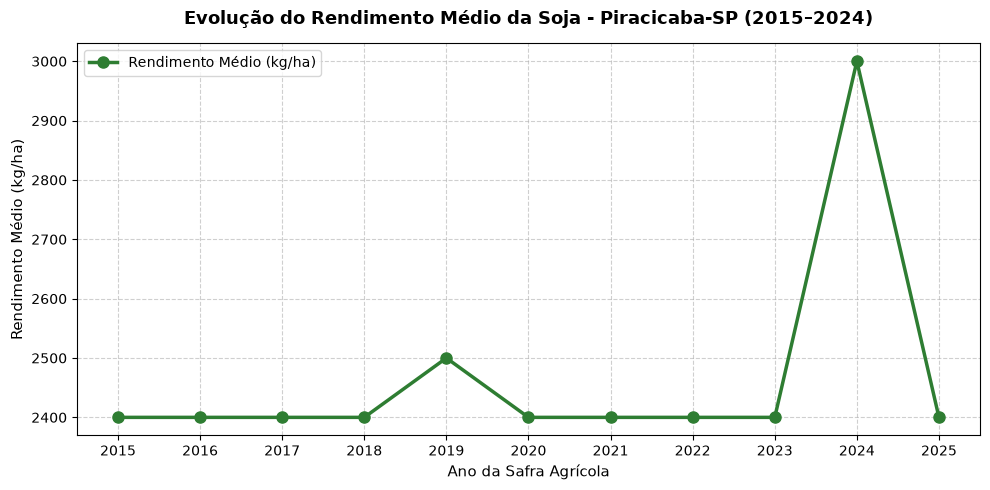

In [16]:
# Visualização temporal da variável de produtividade histórica da soja
plt.figure(figsize=(10, 5))
plt.plot(
    df_integrado["ano"],
    df_integrado["rendimento_kg_ha"],
    marker="o",
    color="#2e7d32",
    linewidth=2.5,
    markersize=8,
    label="Rendimento Médio (kg/ha)"
)
plt.title("Evolução do Rendimento Médio da Soja - Piracicaba-SP (2015–2024)", fontsize=13, fontweight="bold", pad=14)
plt.xlabel("Ano da Safra Agrícola", fontsize=11)
plt.ylabel("Rendimento Médio (kg/ha)", fontsize=11)
plt.xticks(df_integrado["ano"].astype(int))
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


## 8. Etapa F - Proposta de Variável-Alvo sem Vazamento de Dados

### 8.1 Princípio de Prevenção a Vazamento (Data Leakage)
- **Informações disponíveis no momento da previsão:** Apenas dados agroclimáticos da janela de cultivo (chuva acumulada, temperaturas médias/máximas, umidade relativa e de solo).
- **Exclusão de variáveis agrícolas pós-evento:** `area_plantada_ha`, `area_colhida_ha`, `quantidade_produzida_t` e o próprio `rendimento_kg_ha` são consolidados pelo IBGE apenas **após o término da colheita**. Portanto, elas **nunca** compõem a matriz de atributos preditores (features) do modelo de Machine Learning, servindo exclusivamente para construção e rotulagem da variável-alvo.

### 8.2 Definição e Limiar da Classe Positiva
- **Classe Positiva (`quebra_safra = 1`):** Evento de interesse crítico (risco de quebra / baixa produtividade agrícola).
- **Classe Negativa (`quebra_safra = 0`):** Safra normal ou com rendimento elevado.
- **Limiar Numérico Adotado:** Com base na média histórica do rendimento em Piracicaba (~2.470 kg/ha), estabelecemos o limiar formal em **2.450 kg/ha**. Safras com rendimento estritamente inferior a 2.450 kg/ha (como as safras padrão de 2.400 kg/ha em anos de menor desempenho) são rotuladas como classe 1, enquanto safras com rendimentos superiores (2.500 e 3.000 kg/ha) são rotuladas como classe 0.

In [17]:
# Construção formal da variável-alvo no DataFrame
limiar_quebra = 2450.0  # Limiar formal em kg/ha (< 2450 indica quebra de safra)

df_integrado["quebra_safra"] = (df_integrado["rendimento_kg_ha"] < limiar_quebra).astype(int)

media_hist = df_integrado["rendimento_kg_ha"].mean()
print(f"Média histórica do rendimento: {media_hist:.2f} kg/ha")
print(f"Limiar adotado para quebra de safra: < {limiar_quebra} kg/ha")

# Listas explícitas de colunas no código (garantia de prevenção a Data Leakage):
colunas_features = ["PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN", "RH2M", "GWETROOT"]
coluna_alvo = "quebra_safra"
colunas_excluidas_vazamento = [
    "area_plantada_ha",
    "area_colhida_ha",
    "quantidade_produzida_t",
    "rendimento_kg_ha",
]

print("\n=== Definição Formal de Variáveis no Código ===")
print("Features preditoras autorizadas (clima):", colunas_features)
print("Variável-alvo:", coluna_alvo)
print("Colunas EXCLUÍDAS das features (Risco de Vazamento):", colunas_excluidas_vazamento)

print("\n=== Tabela com Rótulos de Quebra de Safra ===")
colunas_visao = ["ano", "rendimento_kg_ha", "quebra_safra"]
print(df_integrado[colunas_visao].to_string(index=False))

print("\n=== Distribuição das Classes (Contagem Absoluta) ===")
print(df_integrado["quebra_safra"].value_counts())

print("\n=== Distribuição das Classes (Percentual) ===")
print(df_integrado["quebra_safra"].value_counts(normalize=True) * 100)


Média histórica do rendimento: 2463.64 kg/ha
Limiar adotado para quebra de safra: < 2450.0 kg/ha

=== Definição Formal de Variáveis no Código ===
Features preditoras autorizadas (clima): ['PRECTOTCORR', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'GWETROOT']
Variável-alvo: quebra_safra
Colunas EXCLUÍDAS das features (Risco de Vazamento): ['area_plantada_ha', 'area_colhida_ha', 'quantidade_produzida_t', 'rendimento_kg_ha']

=== Tabela com Rótulos de Quebra de Safra ===
 ano  rendimento_kg_ha  quebra_safra
2015            2400.0             1
2016            2400.0             1
2017            2400.0             1
2018            2400.0             1
2019            2500.0             0
2020            2400.0             1
2021            2400.0             1
2022            2400.0             1
2023            2400.0             1
2024            3000.0             0
2025            2400.0             1

=== Distribuição das Classes (Contagem Absoluta) ===
quebra_safra
1    9
0    2
Name: cou